In [ ]:
import model_library as ml
import learning_rates as lr

import numpy as np

from keras.callbacks import ModelCheckpoint

from matplotlib import pyplot as plt

from experiments import synthetic_data_alignment

from importlib import reload

2024-11-03 00:59:52.896328: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-03 00:59:52.916801: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-03 00:59:52.916820: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-03 00:59:52.917414: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-03 00:59:52.921112: I tensorflow/core/platform/cpu_feature_guar

In [2]:
X,Y = synthetic_data_alignment(num_samples=10**5, num_features=256, seq_length=512, p_other=0.3)

In [3]:
X.shape

(100000, 512)

In [4]:
Y.shape

(100000, 256)

In [5]:
np.sum(X[0][X[0] != 2][0:256] ^ Y[0])

0

In [6]:
vgg_model = ml.VGG_1D(512, 32, [32,64,128,128],[512,512,512], output_activation='sigmoid',dense_batch_norm=True)

2024-11-03 01:00:13.920882: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-11-03 01:00:13.953452: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-11-03 01:00:13.953563: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [7]:
vgg_model.compile(optimizer='adam',loss='binary_crossentropy',metrics='binary_accuracy')

In [24]:
lr_cyclic = lr.lr_cyclic_sawtooth(20, lr_max=0.001, lr_min = 1e-5, shift=10)

In [16]:
check = ModelCheckpoint('vgg_model_synthetic.keras', monitor='val_loss', save_best_only=True)
vgg_model.fit(X,Y[:,0:32], epochs=101, batch_size=32, validation_split=0.1, callbacks=[lr_cyclic, check])

Epoch 1/101
2813/2813 [==============================] - 30s 10ms/step - loss: 0.8316 - binary_accuracy: 0.5126 - val_loss: 0.7930 - val_binary_accuracy: 0.5264 - lr: 1.0000e-05
Epoch 2/101
2813/2813 [==============================] - 25s 9ms/step - loss: 0.7000 - binary_accuracy: 0.5829 - val_loss: 0.6626 - val_binary_accuracy: 0.6140 - lr: 1.0900e-04
Epoch 3/101
2813/2813 [==============================] - 25s 9ms/step - loss: 0.6237 - binary_accuracy: 0.6461 - val_loss: 0.5870 - val_binary_accuracy: 0.6754 - lr: 2.0800e-04
Epoch 4/101
2813/2813 [==============================] - 22s 8ms/step - loss: 0.5453 - binary_accuracy: 0.7038 - val_loss: 0.4936 - val_binary_accuracy: 0.7385 - lr: 3.0700e-04
Epoch 5/101
2813/2813 [==============================] - 24s 9ms/step - loss: 0.4807 - binary_accuracy: 0.7461 - val_loss: 0.4422 - val_binary_accuracy: 0.7687 - lr: 4.0600e-04
Epoch 6/101
2813/2813 [==============================] - 27s 10ms/step - loss: 0.4402 - binary_accuracy: 0.7701 - 

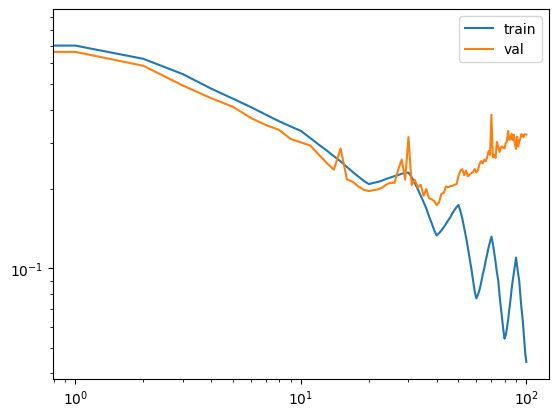

In [17]:
h = vgg_model.history.history
plt.yscale('log')
plt.xscale('log')
plt.plot(h['loss'])
plt.plot(h['val_loss'])
plt.legend(['train','val'])
plt.show()

In [7]:
Xt, Yt = synthetic_data_alignment(num_samples=10**5, num_features=256, seq_length=512, p_other=0.3)
vgg_model.load_weights('vgg_model_synthetic.keras')
Zt_vgg = vgg_model.predict(Xt,batch_size=32)

2024-11-03 01:00:26.020403: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8902


3125/3125 [==============================] - 5s 1ms/step


In [8]:
Zt_vgg_bin = Zt_vgg > 0.5

In [9]:
acc_vgg = np.mean(Zt_vgg_bin == Yt[:,0:32], axis=0)

In [10]:
acc_vgg

array([0.99985, 0.99953, 0.99942, 0.99896, 0.99835, 0.99752, 0.99629,
       0.99478, 0.99289, 0.99004, 0.98792, 0.98507, 0.98117, 0.97694,
       0.96992, 0.96026, 0.95183, 0.94395, 0.92831, 0.90962, 0.89365,
       0.87778, 0.86475, 0.85444, 0.84572, 0.83618, 0.83036, 0.82991,
       0.82366, 0.80467, 0.78335, 0.74326])

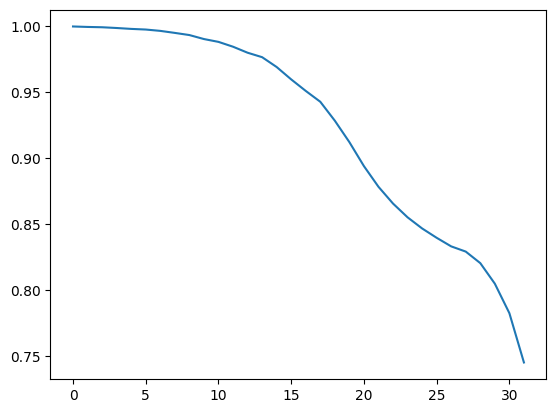

In [12]:
plt.plot(acc_vgg)

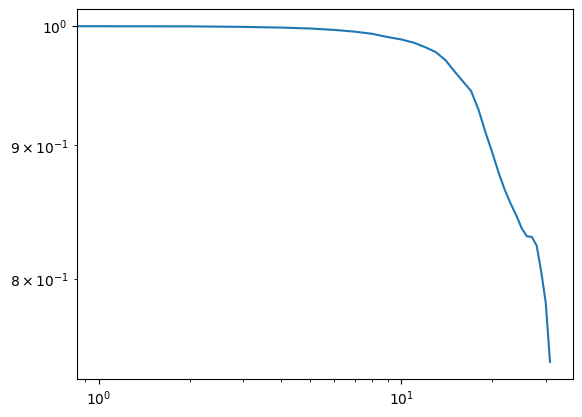

In [11]:
plt.yscale('log')
plt.xscale('log')
plt.plot(acc_vgg)


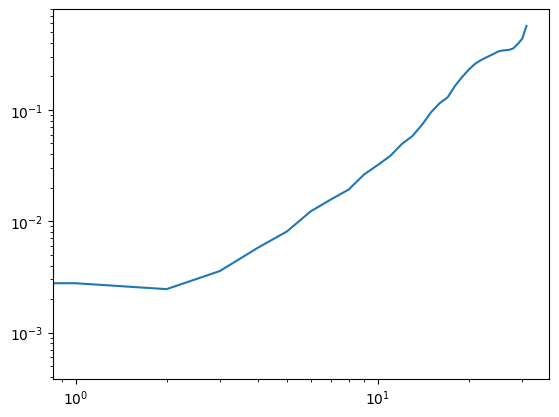

In [13]:
bce_vgg = -Yt[:,0:32] * np.log(Zt_vgg + 1e-7) - (1-Yt[:,0:32]) * np.log(1-Zt_vgg + 1e-7)
bce_vgg_mean = np.mean(bce_vgg, axis=0)

plt.yscale('log') 
plt.xscale('log')
plt.plot(bce_vgg_mean)


Linear regression on BCE log values:
Slope: 2.1308
Intercept: -8.2227
R-squared: 0.9708
P-value: 1.3814e-24
Standard error: 0.0674


Text(0.5, 1.0, 'Log-Log Plot with Linear Fit')

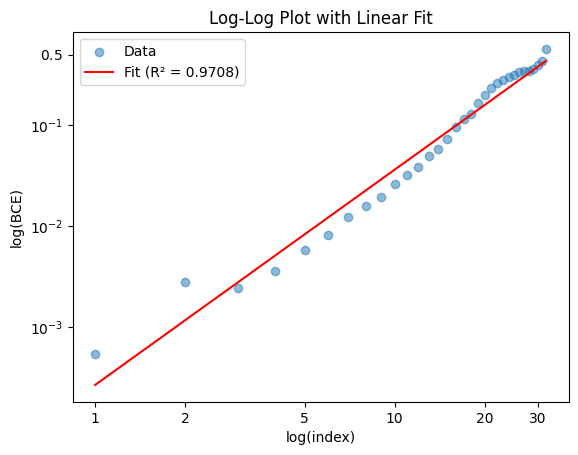

In [14]:
# Fit linear regression to BCE log values
from scipy import stats

# Take log of x and y values, dropping any infinite/nan values
x = np.log(np.arange(1, len(bce_vgg_mean)+1))
y = np.log(bce_vgg_mean)
mask = np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]

# Perform linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

print(f"Linear regression on BCE log values:")
print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}") 
print(f"R-squared: {r_value**2:.4f}")
print(f"P-value: {p_value:.4e}")
print(f"Standard error: {std_err:.4f}")

# Plot regression line
plt.figure()
plt.gca().set_xticks([np.log(x) for x in [1, 2, 5, 10, 20, 30]])
plt.gca().set_xticklabels(['1', '2', '5', '10', '20', '30'])
plt.gca().set_yticks([np.log(y) for y in [0.001, 0.01, 0.1, 0.5, 0.9, 1]])
plt.gca().set_yticklabels(['$10^{-3}$','$10^{-2}$','$10^{-1}$','$0.5$','$0.9$','$1$'])
plt.scatter(np.log(np.arange(1, len(bce_vgg_mean)+1)), np.log(bce_vgg_mean), alpha=0.5, label='Data')
plt.plot(x, slope*x + intercept, 'r', label=f'Fit (R² = {r_value**2:.4f})')
plt.xlabel('log(index)')
plt.ylabel('log(BCE)')
plt.legend()
plt.title('Log-Log Plot with Linear Fit')

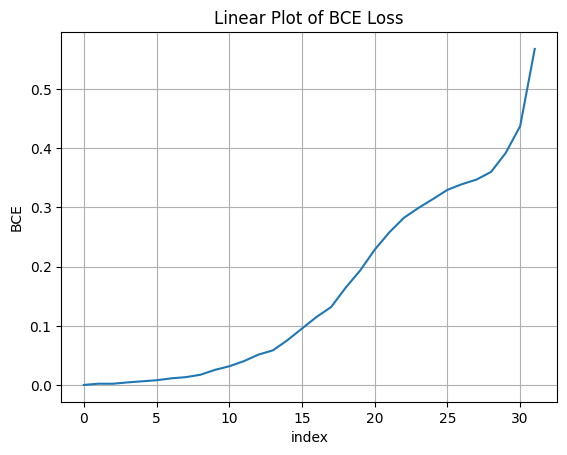

In [16]:
# Plot BCE loss on linear scale
plt.figure()
plt.plot(bce_vgg_mean)
plt.xlabel('index')
plt.ylabel('BCE')
plt.title('Linear Plot of BCE Loss')
plt.grid(True)


Fitted parameters:
a = 0.0241
e₀ = -0.9675


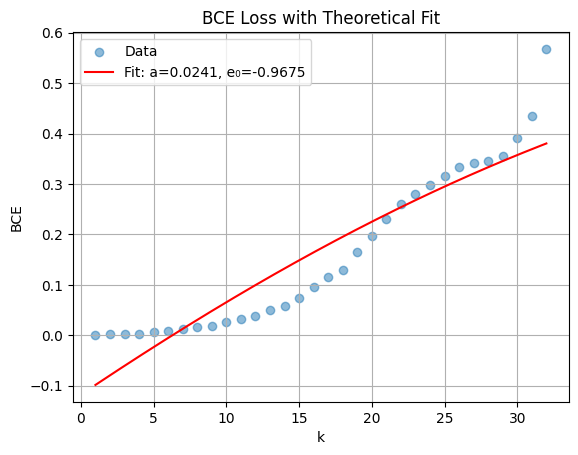

In [15]:
# Fit custom curve to BCE data
from scipy.optimize import curve_fit

def bce_model(k, a, e_0):
    # k is 1-based index, so subtract 1 to match data
    return -0.5 * np.log(0.25 - e_0 * np.exp(-2*a*(k-1)))

# Prepare data for fitting
k_data = np.arange(1, len(bce_vgg_mean)+1)
y_data = bce_vgg_mean

# Initial parameter guesses
p0 = [0.1, 0.1]  # Initial guesses for a and e_0

# Fit curve
try:
    popt, pcov = curve_fit(bce_model, k_data, y_data, p0=p0)
    a_fit, e0_fit = popt
    
    # Generate points for smooth curve
    k_smooth = np.linspace(1, len(bce_vgg_mean), 200)
    y_fit = bce_model(k_smooth, a_fit, e0_fit)
    
    # Plot results
    plt.figure()
    plt.scatter(k_data, y_data, alpha=0.5, label='Data')
    plt.plot(k_smooth, y_fit, 'r-', label=f'Fit: a={a_fit:.4f}, e₀={e0_fit:.4f}')
    plt.xlabel('k')
    plt.ylabel('BCE')
    plt.title('BCE Loss with Theoretical Fit')
    plt.legend()
    plt.grid(True)
    
    print(f"Fitted parameters:")
    print(f"a = {a_fit:.4f}")
    print(f"e₀ = {e0_fit:.4f}")
    
except RuntimeError:
    print("Error: Could not fit curve to data. Try adjusting initial parameters or model.")


Power Law parameters:
a = 0.0002
b = 2.2090


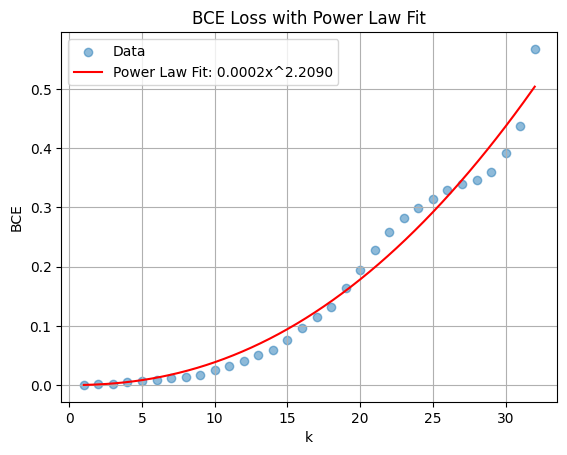

In [18]:
# Fit power law to BCE data
def power_law(x, a, b):
    return a * x**b

# Prepare data for power law fit
k_data = np.arange(1, len(bce_vgg_mean)+1)
y_data = bce_vgg_mean

# Fit power law curve
popt_power, pcov_power = curve_fit(power_law, k_data, y_data)
a_power, b_power = popt_power

# Generate points for smooth curve
k_smooth = np.linspace(1, len(bce_vgg_mean), 200)
y_fit_power = power_law(k_smooth, a_power, b_power)

# Plot results
plt.figure()
plt.scatter(k_data, y_data, alpha=0.5, label='Data')
plt.plot(k_smooth, y_fit_power, 'r-', label=f'Power Law Fit: {a_power:.4f}x^{b_power:.4f}')
plt.xlabel('k')
plt.ylabel('BCE')
plt.title('BCE Loss with Power Law Fit')
plt.legend()
plt.grid(True)

print(f"Power Law parameters:")
print(f"a = {a_power:.4f}")
print(f"b = {b_power:.4f}")


In [16]:
nc = ml.net_ches_2018(32, 8, 64, width=256, depth=20, output_activation='sigmoid')
nc.compile(optimizer='adam',loss='binary_crossentropy',metrics='binary_accuracy')
nc_check = ModelCheckpoint('nc_model_synthetic.keras', monitor='val_loss', save_best_only=True)

In [34]:
nc.fit(X,Y[:,0:32],epochs=21, batch_size=32,validation_split=0.1,callbacks=[lr_cyclic, nc_check])

Epoch 1/21
2813/2813 [==============================] - 46s 14ms/step - loss: 1.0439 - binary_accuracy: 0.5028 - val_loss: 0.7830 - val_binary_accuracy: 0.5050 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 37s 13ms/step - loss: 0.7600 - binary_accuracy: 0.5336 - val_loss: 0.7414 - val_binary_accuracy: 0.5522 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 39s 14ms/step - loss: 0.7291 - binary_accuracy: 0.5748 - val_loss: 0.7211 - val_binary_accuracy: 0.5754 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 42s 15ms/step - loss: 0.7034 - binary_accuracy: 0.5965 - val_loss: 0.6888 - val_binary_accuracy: 0.6001 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 42s 15ms/step - loss: 0.6725 - binary_accuracy: 0.6182 - val_loss: 0.6459 - val_binary_accuracy: 0.6276 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 41s 15ms/step - loss: 0.6310 - binary_accuracy: 0.6458 - va

In [17]:
nc.load_weights('nc_model_synthetic.keras')
Zt_nc = nc.predict(Xt,batch_size=32)

3125/3125 [==============================] - 12s 4ms/step


In [18]:
Zt_nc_bin = Zt_nc > 0.5

In [19]:
acc_nc = np.mean(Zt_nc_bin == Yt[:,0:32], axis=0)

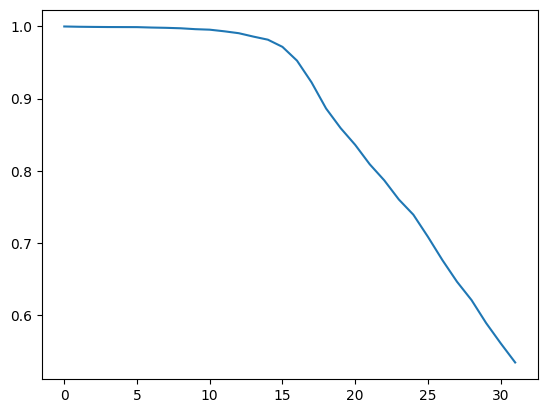

In [20]:
plt.plot(acc_nc)

Text(0.5, 1.0, 'Log-Log Plot of BCE Loss')

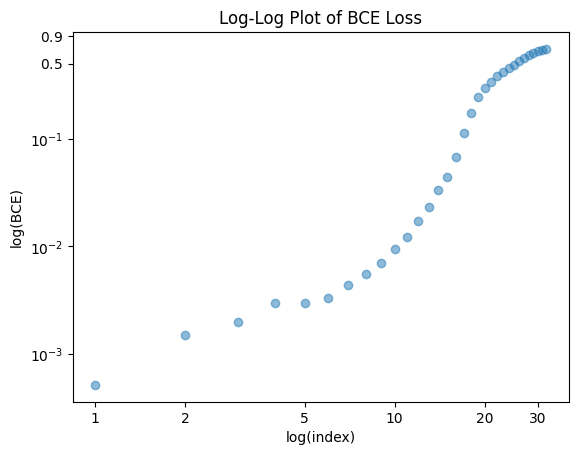

In [21]:
# Compute binary cross entropy loss for each bit position
bce_nc = []
for i in range(32):
    bce_nc.append(-Yt[:,i] * np.log(Zt_nc[:,i] + 1e-7) - (1-Yt[:,i]) * np.log(1-Zt_nc[:,i] + 1e-7))
bce_nc = np.array(bce_nc)

bce_nc_mean = np.mean(bce_nc, axis=0)
# Calculate mean BCE loss for each bit position
bce_nc_mean = np.mean(bce_nc, axis=1)  # Average across samples for each bit position

# Sort values from smallest to largest for clearer trend visualization
indices = np.argsort(bce_nc_mean)
bce_nc_mean = bce_nc_mean[indices]

# Remove any invalid values
valid_mask = ~np.isnan(bce_nc_mean) & ~np.isinf(bce_nc_mean) & (bce_nc_mean > 0)
bce_nc_mean = bce_nc_mean[valid_mask]


# Plot BCE loss on log-log scale
plt.figure()
plt.gca().set_xticks([np.log(x) for x in [1, 2, 5, 10, 20, 30]])
plt.gca().set_xticklabels(['1', '2', '5', '10', '20', '30'])
plt.gca().set_yticks([np.log(y) for y in [0.001, 0.01, 0.1, 0.5, 0.9, 1]])
plt.gca().set_yticklabels(['$10^{-3}$','$10^{-2}$','$10^{-1}$','$0.5$','$0.9$','$1$'])
plt.scatter(np.log(np.arange(1, len(bce_nc_mean)+1)), np.log(bce_nc_mean), alpha=0.5, label='Data')
plt.xlabel('log(index)')
plt.ylabel('log(BCE)')
plt.title('Log-Log Plot of BCE Loss')
